# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head()

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [2]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


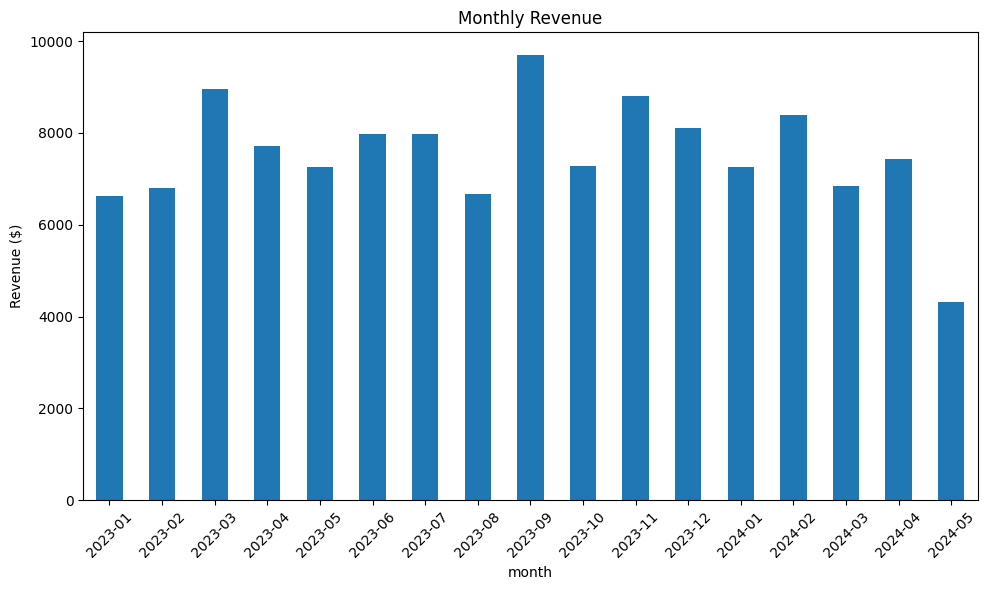

In [3]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

In [5]:
# Your code here
df['order_date'] = pd.to_datetime(df['order_date'])

#get the most recent quarter
latest_date = df['order_date'].max()
quarter = latest_date.quarter
year = latest_date.year

# FIlter to get that quarter
last_quarter_df = df[(df['order_date'].dt.quarter == quarter) &
                     (df['order_date'].dt.year == year)]

# calculate and break down by month
monthly_revenue_q = (
    last_quarter_df.groupby(df['order_date'].dt.strftime('%B'))
                   .agg(total_revenue=('revenue', 'sum'))
                   .sort_index()
)

# get total revenue
total_q_revenue = last_quarter_df['revenue'].sum()

print(f"🧾 Year {year} Q{quarter} — Total Revenue: ${total_q_revenue:,.2f}")
print("\nMonthly Breakdown:")
print(monthly_revenue_q)

🧾 Year 2024 Q2 — Total Revenue: $11,745.00

Monthly Breakdown:
            total_revenue
order_date               
April             7430.29
May               4314.71


### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

In [6]:
# Your code here
top_customers = (
    df.groupby('customer_id')
      .agg(total_revenue=('revenue', 'sum'),
           orders=('order_id', 'count'))
      .sort_values(by='total_revenue', ascending=False)
      .head(5)
)
print(top_customers)

             total_revenue  orders
customer_id                       
62                 4448.39      14
24                 3369.44       9
90                 2976.78      10
92                 2838.74       8
97                 2835.62       8


### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

In [11]:
# Your code here
segment_revenue = (
    df.groupby('customer_segment')
      .agg(total_revenue=('revenue', 'sum'),
           avg_order_value=('revenue', 'mean'),
           orders=('order_id', 'count'))
      .sort_values(by= 'total_revenue', ascending = False))

print(segment_revenue)

                  total_revenue  avg_order_value  orders
customer_segment                                        
Student                52285.29       253.812087     206
Professional           47807.05       255.652674     187
Senior                 28048.33       262.133925     107


### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

In [12]:
# Your code here
region_revenue = (
    df.groupby('region')
      .agg(total_revenue=('revenue', 'sum'),
           orders=('order_id', 'count'))
      .sort_values(by='total_revenue', ascending=False)
)
print(region_revenue)


        total_revenue  orders
region                       
South        34839.45     127
North        34351.69     133
East         31221.80     130
West         27727.73     110


### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

In [16]:
# Your code here
category_performance = (
    df.groupby('product_category')
      .agg(total_revenue=('revenue', 'sum'),
           quantity_sold=('quantity', 'sum'),
           avg_price=('unit_price', 'mean'))
      .sort_values(by='total_revenue', ascending=False)
)
print(category_performance)


                  total_revenue  quantity_sold   avg_price
product_category                                          
Home                   29871.47            269  108.447059
Electronics            25498.31            239  107.996465
Clothing               24804.57            253   99.120769
Books                  24046.06            227  102.714301
Sports                 23920.26            246   99.465000


### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

In [19]:
# Your code here
discount_summary = (
    df.groupby('discount_applied')
      .agg(orders=('order_id', 'count'),
           total_revenue=('revenue', 'sum'),
           avg_revenue_per_order=('revenue', 'mean'))
        .sort_values(by='avg_revenue_per_order', ascending=False)
)
print(discount_summary)


                  orders  total_revenue  avg_revenue_per_order
discount_applied                                              
25                    30        9040.83             301.361000
15                    49       13906.68             283.809796
5                     59       15747.94             266.914237
10                    44       11639.38             264.531364
0                    243       60336.01             248.296337
30                    44       10780.34             245.007727
20                    31        6689.49             215.790000


### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

In [21]:
# Your code here
payment_usage = (
    df.groupby('payment_method')
      .agg(orders=('order_id', 'count'),
           total_revenue=('revenue', 'sum'))
      .sort_values(by='total_revenue', ascending=False)
)
print(payment_usage)


                orders  total_revenue
payment_method                       
Credit Card        137       35269.86
Debit Card         123       33945.62
Gift Card          124       31540.95
PayPal             116       27384.24


### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

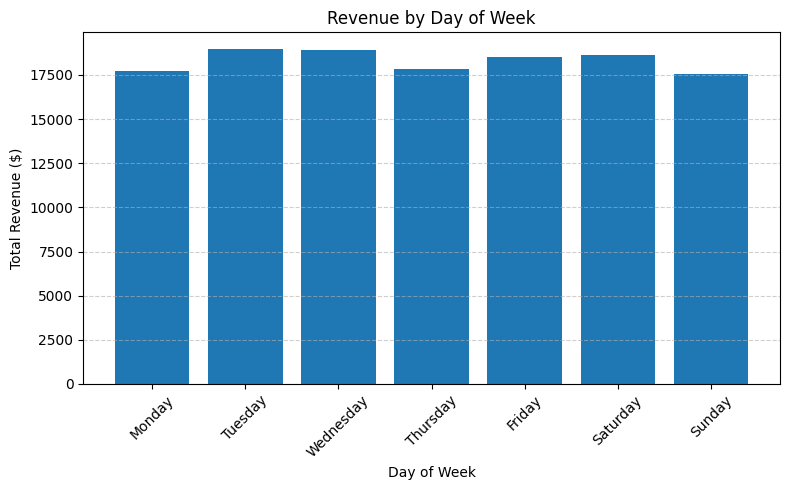

Weekend Revenue: $36,190.59
Weekday Revenue: $91,950.08
Weekdays generate more revenue.


In [22]:
# Your code here
import matplotlib.pyplot as plt

df['order_date'] = pd.to_datetime(df['order_date'])
df['day_of_week'] = df['order_date'].dt.day_name()

revenue_by_day = (
    df.groupby('day_of_week')
      .agg(total_revenue=('revenue', 'sum'))
      .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)

plt.figure(figsize=(8,5))
plt.bar(revenue_by_day.index, revenue_by_day['total_revenue'])
plt.title("Revenue by Day of Week")
plt.ylabel("Total Revenue ($)")
plt.xlabel("Day of Week")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

weekend_revenue = revenue_by_day.loc[['Saturday', 'Sunday']].sum().values[0]
weekday_revenue = revenue_by_day.loc[['Monday','Tuesday','Wednesday','Thursday','Friday']].sum().values[0]

print(f"Weekend Revenue: ${weekend_revenue:,.2f}")
print(f"Weekday Revenue: ${weekday_revenue:,.2f}")

if weekend_revenue > weekday_revenue / 2:
    print("Weekends are busier.")
else:
    print("Weekdays generate more revenue.")


### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

In [23]:
# Your code here
df['profit'] = df['revenue'] * 0.20
total_profit = df['profit'].sum()
region_profit = (
    df.groupby('region')
      .agg(total_profit=('profit', 'sum'))
      .sort_values(by='total_profit', ascending=False)
)
print(f"Total Profit: ${total_profit:,.2f}\n")
print(region_profit)


Total Profit: $25,628.13

        total_profit
region              
South       6967.890
North       6870.338
East        6244.360
West        5545.546


### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

My recommendation is to focus on the West and to give promotional offers as their total revenue lacks especially when compared to the north and south. The east is around $3k behind that of the south and north whereas the West is $6k. I do also believe something should be done to reach the seniors as they are spendind the least amount but could potentially be spending more if marketed correctly. Its not that they aren't ordering enough, it's more that not enough are ordering, about 50% to that of students which is a shame because they do spend around the same % per order.

---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.